# SARIMAX Modeling

The Neural Prophet library is not being updated. There are known issues in using Neural Prophet with newer versions of numpy.

## Import Packages

In [53]:
import requests 
import os
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from pandas.tseries.holiday import USFederalHolidayCalendar
import itertools
import optuna
import logging

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar


## Import Data

In [54]:
rat_sighting = pd.read_csv("../scr/data/rat_sightings_data/Rat_Sightings_NYC.csv")
rat_sighting.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in rat_sighting.columns] #apply to column headers
rat_sighting['location_type'] = rat_sighting['location_type'].str.strip().str.replace(' ', '_').str.lower()  #apply to location_type column
cols_to_drop = [c for c in rat_sighting.columns if (rat_sighting[c].nunique(dropna=False) == 1)]
rat_sighting = rat_sighting.drop(columns=cols_to_drop)
rat_sighting['created_date'] = pd.to_datetime(rat_sighting['created_date']) 
rat_sighting = rat_sighting.drop(columns='park_borough')
rat_sighting = rat_sighting.drop(columns=['location'])
rs = rat_sighting.copy()
rs['created_date'] = pd.to_datetime(rs['created_date']) 
rs = rs[rs['created_date']>='2020-01-01']
rs = rs.groupby([rs['created_date'].dt.date]).size().reset_index(name='count')
rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)

lat, lon = 40.7831, -73.9712
last_date = rs['ds'].max()
start = "2020-01-01"
end   = last_date.strftime("%Y-%m-%d")  # use last date of rs

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd['ds'] = pd.to_datetime(nd['date'])
    wd = nd.drop(columns=['date'])
else:
    wd = pd.DataFrame(data["daily"])
    wd["ds"] = pd.to_datetime(wd["time"])
    wd = wd.drop(columns=["time"])

wd = wd.reset_index(drop=True)
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=14,
                             freq='D')

last_row = wd.iloc[-1]
wd_14 = pd.DataFrame([last_row.values] * 14, columns=wd.columns)
wd_14['ds'] = future_dates 
wd_14 = wd_14.reset_index(drop=True)

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

wd["ds"] = pd.to_datetime(wd["ds"])
wd_14["ds"] = pd.to_datetime(wd_14["ds"])

rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(wd[['ds'] + regressed_features], on="ds", how="left")

rs

WARNING - (py.warnings._showwarnmsg) - C:\Users\daoke\AppData\Local\Temp\ipykernel_27492\3708558684.py:6: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.




,ds,y,apparent_temperature_max,apparent_temperature_min,snowfall_sum
0,2020-01-01,17,-0.3,-5.3,0.00
1,2020-01-02,40,4.5,-6.6,0.00
2,2020-01-03,41,7.3,-1.1,0.00
3,2020-01-04,25,7.9,1.0,0.00
4,2020-01-05,17,-1.0,-5.0,0.00
...,...,...,...,...,...
2252,2026-03-02,40,-5.6,-15.2,0.00
2253,2026-03-03,34,-2.1,-10.2,1.75
2254,2026-03-04,45,6.3,-2.3,0.00
2255,2026-03-05,55,3.0,-1.2,0.00


## Tune Hyperparameters and Cross Validate to Check

In [55]:
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']
tscv_splits = 26
tscv_test_size = 14
fourier_K = 60 # number of Fourier terms
yearly_period = 365.25 # accounts for leap years
weekly_seasonality = 7 # as a reminder we are using weekly seasonality




cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])



exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)



stepwise_model = auto_arima(
    rs['y'],
    exogenous=exog,
    seasonal=True,
    m=weekly_seasonality,  # weekly seasonality
    stepwise=True,
    trace=True,
    suppress_warnings=True,
    error_action='ignore',
    n_jobs=-1  # use all available CPU cores
)
print("Auto ARIMA selected orders:", stepwise_model.order, stepwise_model.seasonal_order)



tscv = TimeSeriesSplit(n_splits=tscv_splits, test_size=tscv_test_size)
rmse_list = []
mape_list = []

for train_idx, test_idx in tscv.split(rs):
    y_train, y_test = rs['y'].iloc[train_idx], rs['y'].iloc[test_idx]
    exog_train, exog_test = exog.iloc[train_idx], exog.iloc[test_idx]
    
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=stepwise_model.order,
        seasonal_order=stepwise_model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    
    pred = model.get_forecast(steps=len(y_test), exog=exog_test).predicted_mean
    
    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))
    mape_list.append(mean_absolute_percentage_error(y_test, pred))

print(f"CV Results -> Avg RMSE: {np.mean(rmse_list):.2f}, Avg MAPE: {np.mean(mape_list)*100:.2f}%")

WARNING - (py.warnings._showwarnmsg) - c:\Users\daoke\anaconda3\Lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning:

stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.




Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=18051.908, Time=6.15 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=19850.584, Time=0.10 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=19164.576, Time=0.76 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=19077.350, Time=0.96 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=19848.585, Time=0.06 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=18841.070, Time=3.64 sec
 ARIMA(2,1,2)(1,0,0)[7] intercept   : AIC=18615.881, Time=2.41 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=18058.461, Time=45.46 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=18053.408, Time=25.10 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=18974.292, Time=1.08 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=18653.349, Time=10.54 sec
 ARIMA(2,1,2)(2,0,0)[7] intercept   : AIC=18392.468, Time=11.31 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=18055.783, Time=16.71 sec
 ARIMA(1,1,2)(1,0,1)[7] intercept   : AIC=18052.342, Time=3.16 sec
 ARIMA(2,1,1)(

Auto ARIMA selected orders: (2, 1, 1) (1, 0, 1, 7)
CV Results -> Avg RMSE: 11.18, Avg MAPE: 22.24%

In [56]:
exog

,fourier_0,fourier_1,fourier_2,fourier_3,fourier_4,fourier_5,fourier_6,fourier_7,fourier_8,fourier_9,...,fourier_114,fourier_115,fourier_116,fourier_117,fourier_118,fourier_119,holiday,apparent_temperature_max,apparent_temperature_min,snowfall_sum
0,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1,-0.3,-5.3,0.00
1,0.017202,0.999852,0.034398,0.999408,0.051584,0.998669,0.068755,0.997634,0.085906,0.996303,...,0.840248,0.542202,0.849450,0.527668,0.858402,0.512978,0,4.5,-6.6,0.00
2,0.034398,0.999408,0.068755,0.997634,0.103031,0.994678,0.137185,0.990545,0.171177,0.985240,...,0.911169,-0.412034,0.896456,-0.443132,0.880683,-0.473706,0,7.3,-1.1,0.00
3,0.051584,0.998669,0.103031,0.994678,0.154204,0.988039,0.204966,0.978769,0.255182,0.966893,...,0.147827,-0.989013,0.096613,-0.995322,0.045141,-0.998981,0,7.9,1.0,0.00
4,0.068755,0.997634,0.137185,0.990545,0.204966,0.978769,0.271777,0.962360,0.337301,0.941397,...,-0.750864,-0.660457,-0.794497,-0.607268,-0.834370,-0.551205,0,-1.0,-5.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2252,0.862782,0.505576,0.872404,-0.488785,0.019352,-0.999813,-0.852837,-0.522178,-0.881699,0.471812,...,-0.623370,-0.781927,-0.989794,0.142508,-0.377462,0.926025,0,-5.6,-15.2,0.00
2253,0.871351,0.490660,0.855075,-0.518505,-0.032249,-0.999480,-0.886721,-0.462305,-0.837909,0.545811,...,-0.995005,0.099823,-0.401229,0.915978,0.601271,0.799045,0,-2.1,-10.2,1.75
2254,0.879662,0.475599,0.836733,-0.547611,-0.083764,-0.996486,-0.916409,-0.400244,-0.787922,0.615774,...,-0.455618,0.890175,0.566362,0.824157,0.994341,-0.106239,0,6.3,-2.3,0.00
2255,0.887713,0.460397,0.817401,-0.576069,-0.135055,-0.990838,-0.941759,-0.336289,-0.732111,0.681185,...,0.500931,0.865487,0.998932,-0.046215,0.418879,-0.908042,0,3.0,-1.2,0.00


## Make the Final Model and Forecast

In [57]:
regressed_features = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']
fourier_K = 5
yearly_period = 365.25
weekly_seasonality = 7
forecast_horizon = 14 
order = (2, 1, 1) 
seasonal_order = (1, 0, 1, 7)  

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=rs['ds'].min(), end=rs['ds'].max())
rs['holiday'] = rs['ds'].isin(holidays).astype(int)

def fourier_series(dates, period, K):
    t = np.arange(len(dates))
    return np.column_stack([func(2 * np.pi * k * t / period)
                            for k in range(1, K+1)
                            for func in (np.sin, np.cos)])

fourier_terms = fourier_series(rs['ds'], yearly_period, fourier_K)
fourier_df = pd.DataFrame(fourier_terms, columns=[f'fourier_{i}' for i in range(fourier_terms.shape[1])])

exog = pd.concat([fourier_df, rs[['holiday'] + regressed_features].reset_index(drop=True)], axis=1)
sarimax_model = SARIMAX(
    rs['y'],
    exog=exog,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

last_date = rs['ds'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_horizon, freq='D')

last_row = rs.iloc[-1]
future_exog_df = pd.DataFrame([last_row[regressed_features + ['holiday']].values] * forecast_horizon,
                              columns=regressed_features + ['holiday'])
future_exog_df['holiday'] = future_dates.isin(holidays).astype(int)  # update holidays

future_fourier = fourier_series(future_dates, yearly_period, fourier_K)
future_fourier_df = pd.DataFrame(future_fourier, columns=fourier_df.columns)

future_exog = pd.concat([future_fourier_df.reset_index(drop=True), future_exog_df.reset_index(drop=True)], axis=1)




forecast = sarimax_model.get_forecast(steps=forecast_horizon, exog=future_exog)
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()
forecast_df = pd.DataFrame({
    'ds': future_dates,
    'forecast': forecast_values,
    'lower_ci': forecast_ci.iloc[:, 0],
    'upper_ci': forecast_ci.iloc[:, 1]
})

print(forecast_df)

             ds   forecast   lower_ci   upper_ci
2257 2026-03-07  10.391069 -13.981904  34.764042
2258 2026-03-08  10.960779 -14.418080  36.339638
2259 2026-03-09  18.878838  -7.102392  44.860069
2260 2026-03-10  18.971126  -7.157289  45.099540
2261 2026-03-11  18.493404  -7.695532  44.682341
2262 2026-03-12  17.526322  -8.686529  43.739174
2263 2026-03-13  17.917702  -8.307320  44.142724
2264 2026-03-14   8.690849 -17.763404  35.145101
2265 2026-03-15  11.008461 -15.480381  37.497302
2266 2026-03-16  19.678667  -6.834049  46.191382
2267 2026-03-17  20.225529  -6.298374  46.749432
2268 2026-03-18  19.974702  -6.556913  46.506316
2269 2026-03-19  19.121113  -7.416295  45.658520
2270 2026-03-20  19.546789  -6.995570  46.089148


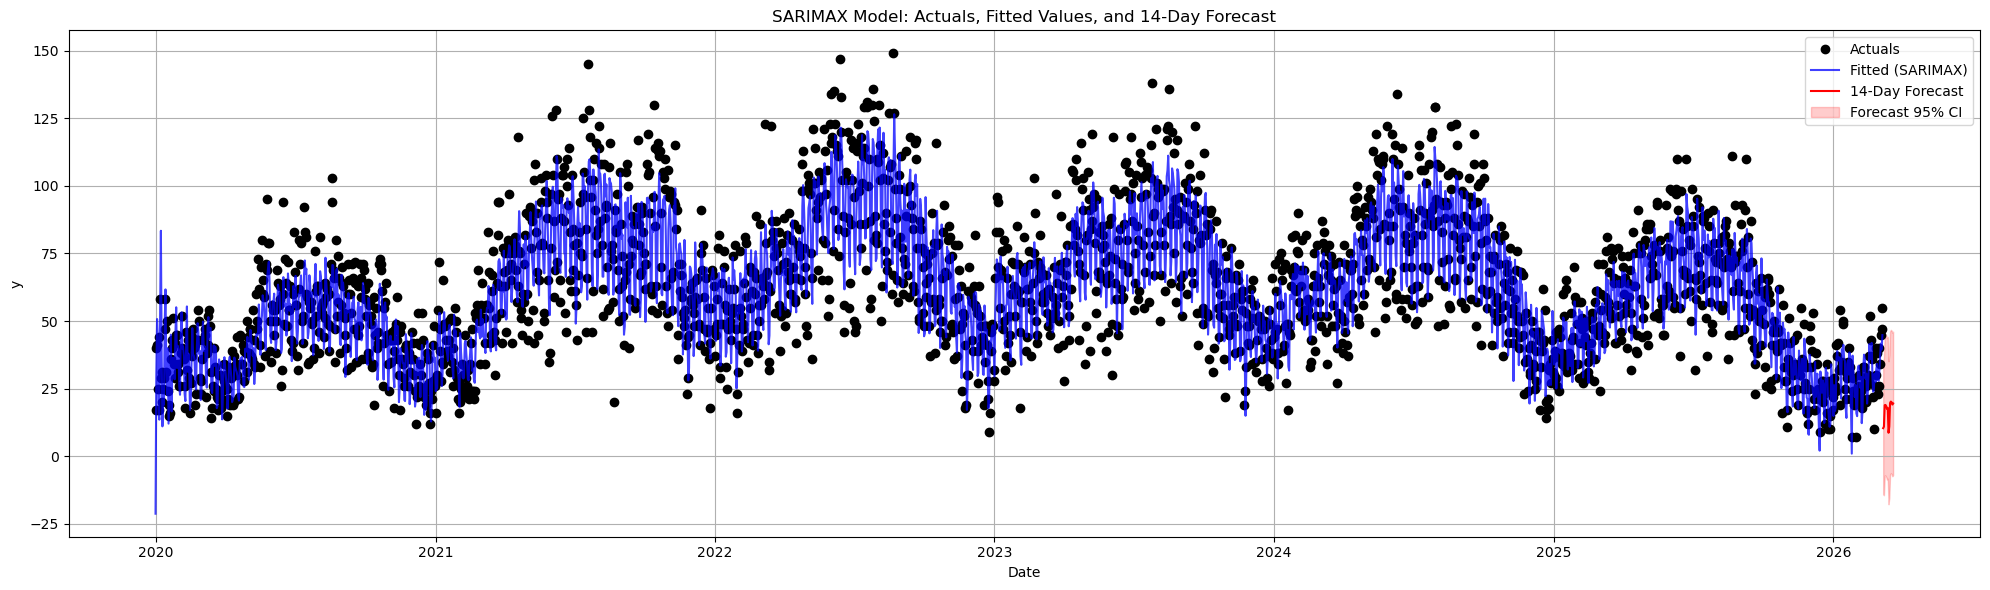

In [58]:
fitted_values = sarimax_model.fittedvalues 

plt.figure(figsize=(20,6))
plt.plot(rs['ds'], rs['y'], label='Actuals', color='black', marker = 'o', linestyle='')
plt.plot(rs['ds'], fitted_values, label='Fitted (SARIMAX)', color='blue', alpha= 0.75)
plt.plot(forecast_df['ds'], forecast_df['forecast'], label='14-Day Forecast', color='red')

plt.fill_between(forecast_df['ds'], 
                 forecast_df['lower_ci'], 
                 forecast_df['upper_ci'], 
                 color='red', alpha=0.2, label='Forecast 95% CI')

plt.xlabel('Date')
plt.ylabel('y')
plt.title('SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [59]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

# Actuals as circles
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=rs['y'],
    mode='markers',  # dots only
    name='Actuals',
    marker=dict(color='black', size=6)
))

# Fitted values as line
fig.add_trace(go.Scatter(
    x=rs['ds'],
    y=sarimax_model.fittedvalues,
    mode='lines',
    name='Fitted (SARIMAX)',
    line=dict(color='blue', width=2),
    opacity=0.75
))

# Forecast as line
fig.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['forecast'],
    mode='lines',
    name='14-Day Forecast',
    line=dict(color='red', width=2)
))

# Forecast confidence interval as filled area
fig.add_trace(go.Scatter(
    x=list(forecast_df['ds']) + list(forecast_df['ds'][::-1]),
    y=list(forecast_df['upper_ci']) + list(forecast_df['lower_ci'][::-1]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Forecast 95% CI'
))

# Layout
fig.update_layout(
    title='SARIMAX Model: Actuals, Fitted Values, and 14-Day Forecast',
    xaxis_title='Date',
    yaxis_title='y',
    legend=dict(x=0, y=1),
    hovermode='x unified',
    width=1000,
    height=500
)

fig.show()